# 후판공정 Scale(산화철) 불량 예측 — 종합 분석 노트북

철강 후판 공정에서 발생하는 **Scale 불량**의 원인을 규명하고, 현업 오퍼레이터가
실시간으로 활용할 수 있는 예측 모델을 만든다.

```
가열로(예열대 → 가열대 → 균열대) → 추출 → HSB(고압수 세척) → 압연 → Scale 판정
```

| 항목 | 내용 |
|---|---|
| 데이터 | 1,000개 슬래브 × 21개 공정 변수 (2023-01-03 ~ 01-10) |
| 타깃 | `scale` — 양품 690 / 불량 310 |
| 목표 | ① 근본 원인 규명 ② 7개 모델 비교 ③ XAI 해석 ④ 대시보드 연계 |

## 목차

0. 환경 설정
1. 데이터 적재 — `preprocessing` 모듈 활용
2. EDA — 왜 가열로 온도와 재로시간이 중요한가
3. Feature Set 설계 — 데이터 누수 방지
4. 7개 모델 비교
5. XAI — 변수 중요도 해석
6. 비용비 기반 임계값 최적화
7. 결론 및 현장 적용 가이드라인

---
## 0. 환경 설정

한글 폰트를 등록하지 않으면 그래프의 한글이 네모(□)로 깨진다.
OS별로 사용 가능한 폰트가 다르므로 후보를 순회하며 잡는다.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# ★ seaborn 스타일을 먼저 적용한다.
#   sns.set_style()이 rcParams를 덮어쓰므로 폰트 설정보다 뒤에 오면
#   한글이 다시 네모(□)로 깨진다.
sns.set_style("whitegrid")

# --- 한글 폰트 설정 -------------------------------------------------
# Windows: Malgun Gothic / macOS: AppleGothic / Linux: NanumGothic 또는 Noto Sans CJK KR
installed = {f.name for f in fm.fontManager.ttflist}
for cand in ["Malgun Gothic", "AppleGothic", "NanumGothic",
             "Noto Sans CJK KR", "Noto Sans KR", "DejaVu Sans"]:
    if cand in installed:
        plt.rcParams["font.family"] = "sans-serif"
        plt.rcParams["font.sans-serif"] = [cand]
        print(f"폰트 설정: {cand}")
        break
else:
    print("한글 폰트를 찾지 못했습니다. NanumGothic 설치를 권장합니다.")

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (11, 4.5)

# 색상 통일 (양품=청색 / 불량=적색)
C_OK, C_NG = "#2a6496", "#c0391b"
PALETTE = {0: C_OK, 1: C_NG}

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

폰트 설정: Noto Sans CJK KR


---
## 1. 데이터 적재

직접 `pd.read_csv`를 호출하지 않고 `preprocessing` 모듈을 임포트한다.
전처리 로직이 노트북과 모델 학습 스크립트, 그리고 나중에 만들 대시보드에서
**완전히 동일하게** 적용되도록 보장하기 위해서다.

노트북에서만 슬쩍 다르게 처리한 전처리가 있으면, 대시보드에 올렸을 때
성능이 재현되지 않는다.

In [2]:
from preprocessing import build_dataset, FEATURE_SETS, get_feature_columns

df = build_dataset("data/SCALE불량.csv")
df.head(3)

[load ] shape : (1000, 21)
[clean] rolling_temp == 0 → NaN : 6건
[clean] 결측 컬럼 : {'rolling_temp': 6}
[clean] 불량률 : 31.0% (310 / 1000)
[feat ] shape : (1000, 34) (파생 12개 추가)


,plate_no,rolling_date,scale,spec_long,spec_country,steel_kind,pt_thick,pt_width,pt_length,hsb,fur_no,fur_input_row,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,fur_total_time,rolling_method,rolling_temp,descaling_count,work_group,target,gap_min,work_hour,surface_area,volume,sa_ratio,aspect,fur_wait_time,heat_index,soak_index,soak_over_1173,is_tm,grade
0,PLT_1001,2023-01-03 07:07:53,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,1열,1144,116,1133,59,259,TMCP(온도제어),934.0,8,1조,0,10.216667,7,112943200,1787840000,0.063173,4.081081,84,132.704,66.847,0,1,EH32
1,PLT_1002,2023-01-03 07:21:22,양품,AB/EH32-TM,미국,T,32,3700,15100,적용,1호기,2열,1144,122,1135,53,238,TMCP(온도제어),937.0,8,1조,0,13.483333,7,112943200,1787840000,0.063173,4.081081,63,139.568,60.155,0,1,EH32
2,PLT_1003,2023-01-03 07:31:15,양품,NV-E36-TM,영국,T,33,3600,19200,적용,2호기,1열,1129,116,1121,55,258,TMCP(온도제어),889.0,8,1조,0,9.883333,7,139744800,2280960000,0.061266,5.333333,87,130.964,61.655,0,1,E36


### 정제 내역 확인

`rolling_temp == 0`인 6건이 `NaN`으로 바뀐 것을 확인한다.
상온 압연은 물리적으로 불가능하므로, 이 0은 온도계 미측정이나 통신 두절을
0으로 코딩한 결측값이다.

In [3]:
print("원본 컬럼 21개 + 파생 12개 =", df.shape[1])
print()
print("결측 현황:")
print(df.isna().sum()[lambda s: s > 0])
print()
print("타깃 분포:")
print(df["scale"].value_counts(), "\n불량률:", f"{df['target'].mean()*100:.1f}%")

원본 컬럼 21개 + 파생 12개 = 34

결측 현황:
rolling_temp    6
dtype: int64

타깃 분포:
scale
양품    690
불량    310
Name: count, dtype: int64 
불량률: 31.0%


---
## 2. EDA — 왜 가열로 온도와 재로시간이 중요한가

### 스케일이 생기는 원리

강재를 1,100~1,200°C로 가열하면 표면 철(Fe)이 산소·수증기와 반응해
산화철 껍질이 생긴다. 층 구조는 안쪽부터
**FeO(뷔스타이트) → Fe₃O₄(마그네타이트) → Fe₂O₃(헤마타이트)**.

여기서 중요한 것은 **불량을 가르는 기준이 "스케일이 생겼느냐"가 아니라
"HSB로 떨어지느냐"** 라는 점이다. 스케일은 반드시 생긴다. 잘 떨어지면 양품이다.

떨어지지 않는 조건은 셋이다.

1. **너무 두꺼움** — 고온·장시간 노출 → 가열로 변수군
2. **너무 치밀함** — 고온 유지로 조직이 여물어 지철에 밀착 → 균열대 변수군
3. **화학적 밀착** — Si 함량이 높으면 페이얄라이트(Fe₂SiO₄, 융점 약 1,173°C)가
   생성되어 액상이 지철 계면에 침투 → 강종 변수군

아래 EDA는 이 세 가설을 데이터로 검증하는 과정이다.

### 2-1. 타깃 분포

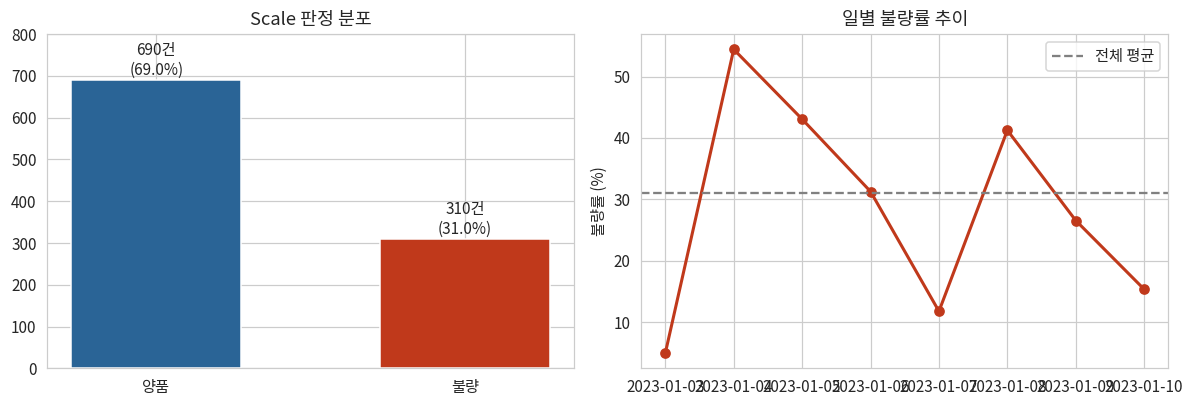

불균형 비율 69:31 — SMOTE 같은 과격한 처치는 불필요.
class_weight 또는 임계값 조정으로 충분한 수준이다.


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

vc = df["scale"].value_counts()
ax[0].bar(vc.index, vc.values, color=[C_OK, C_NG], width=0.55)
for i, v in enumerate(vc.values):
    ax[0].text(i, v + 12, f"{v}건\n({v/len(df)*100:.1f}%)", ha="center", fontsize=10)
ax[0].set_title("Scale 판정 분포", fontsize=12, fontweight="bold")
ax[0].set_ylim(0, 800)

# 시간 흐름에 따른 일별 불량률
daily = df.set_index("rolling_date").resample("D")["target"].agg(["mean", "count"])
ax[1].plot(daily.index, daily["mean"] * 100, marker="o", color=C_NG, lw=2)
ax[1].axhline(df["target"].mean() * 100, ls="--", c="gray", label="전체 평균")
ax[1].set_title("일별 불량률 추이", fontsize=12, fontweight="bold")
ax[1].set_ylabel("불량률 (%)")
ax[1].legend()
plt.tight_layout(); plt.show()

print("불균형 비율 69:31 — SMOTE 같은 과격한 처치는 불필요.")
print("class_weight 또는 임계값 조정으로 충분한 수준이다.")

### 2-2. 가열로 온도 3종 — 가설 1 검증

**가설**: 온도가 높을수록 산화가 격렬해져 스케일이 두꺼워진다.

`fur_heat_temp`(가열대), `fur_soak_temp`(균열대), `rolling_temp`(압연) 세 온도를
양품/불량으로 나눠 분포를 비교한다.

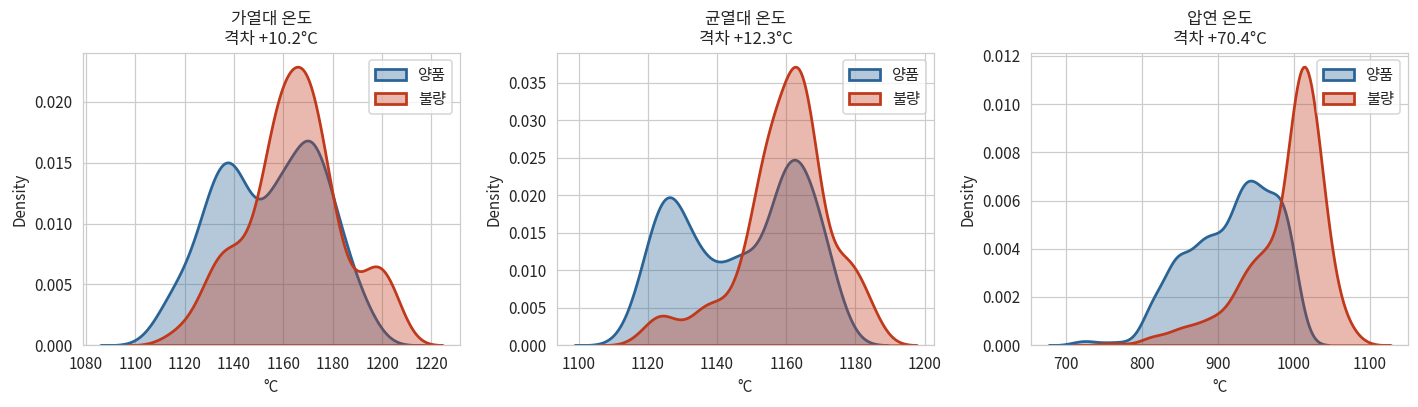

,양품 평균,불량 평균,격차
fur_heat_temp,1154.1,1164.3,10.2
fur_soak_temp,1147.1,1159.4,12.3
rolling_temp,918.3,988.8,70.4


In [5]:
temps = [("fur_heat_temp", "가열대 온도"),
         ("fur_soak_temp", "균열대 온도"),
         ("rolling_temp", "압연 온도")]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (col, name) in zip(axes, temps):
    for t, lab in [(0, "양품"), (1, "불량")]:
        sns.kdeplot(df.loc[df.target == t, col].dropna(), ax=ax,
                    fill=True, alpha=.35, color=PALETTE[t], label=lab, lw=1.8)
    g = df.groupby("target")[col].mean()
    ax.set_title(f"{name}\n격차 +{g[1]-g[0]:.1f}°C", fontsize=11, fontweight="bold")
    ax.set_xlabel("°C"); ax.legend()
plt.tight_layout(); plt.show()

gap = pd.DataFrame({
    "양품 평균": df[df.target == 0][[c for c, _ in temps]].mean(),
    "불량 평균": df[df.target == 1][[c for c, _ in temps]].mean(),
})
gap["격차"] = gap["불량 평균"] - gap["양품 평균"]
display(gap.round(1))

**해석**

세 온도 모두 불량 쪽이 높다. 가설 1이 지지된다.

특히 `rolling_temp`의 격차가 **+78.5°C**로 압도적이다. 이것은 도메인에서
말하는 **"스케일의 마지막 확정치"** 개념과 정확히 맞물린다. 가열로에서 아무리
온도를 잘 잡아도 압연 직전 온도가 높으면 스케일이 마지막으로 한 번 더 급격히
성장·치밀화되어 HSB로도 떼어내기 힘든 난제거성 스케일이 된다.

> ⚠️ 다만 `rolling_temp`는 **압연이 끝나야 알 수 있는 값**이다.
> 이 문제는 3장에서 Feature Set을 나누는 근거가 된다.

### 2-3. 재로시간 — 가설이 뒤집히는 지점

**가설**: 고온 노출 시간이 길수록 산화철이 두껍게 자란다.

그런데 데이터는 반대로 나온다.

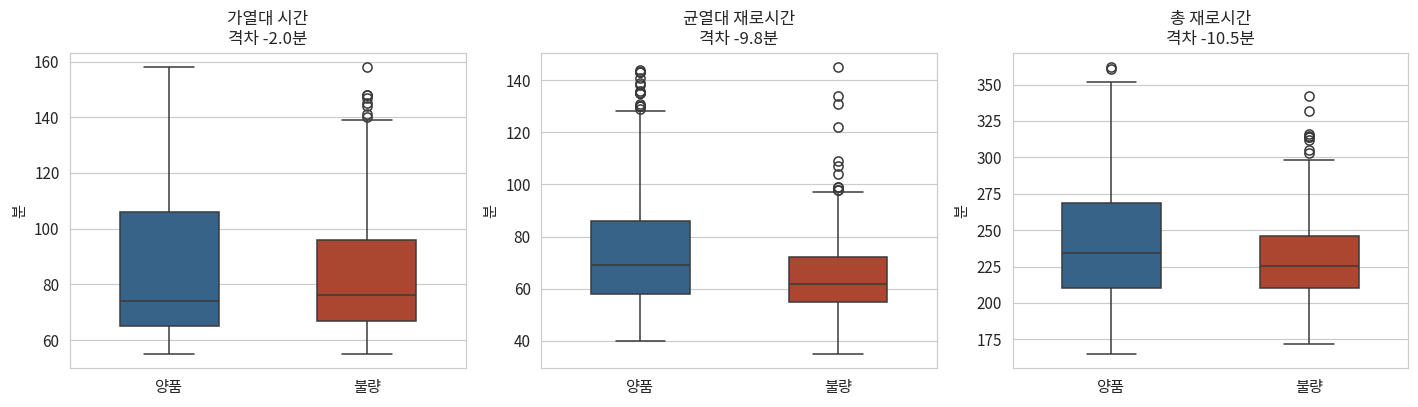

In [6]:
times = [("fur_heat_time", "가열대 시간"),
         ("fur_soak_time", "균열대 재로시간"),
         ("fur_total_time", "총 재로시간")]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (col, name) in zip(axes, times):
    sns.boxplot(data=df, x="scale", y=col, ax=ax, width=.5,
                palette={"양품": C_OK, "불량": C_NG}, order=["양품", "불량"])
    g = df.groupby("target")[col].mean()
    ax.set_title(f"{name}\n격차 {g[1]-g[0]:+.1f}분", fontsize=11, fontweight="bold")
    ax.set_xlabel(""); ax.set_ylabel("분")
plt.tight_layout(); plt.show()

**해석 — 여기가 이 프로젝트에서 가장 흥미로운 지점이다**

시간 3종 모두 **불량 쪽이 오히려 짧다**. 도메인 가설과 정반대다.

그렇다고 가설이 틀린 것은 아니다. 산화 속도는

$$k = A \cdot e^{-E_a / RT}$$

아레니우스 식을 따르므로 **온도에 대해서는 지수적**이고 **시간에 대해서는
선형에 가깝다**. 즉 같은 열량을 투입하더라도

- **고온 · 단시간** → 산화 격렬
- **저온 · 장시간** → 산화 완만

가 된다. 데이터의 "불량 쪽 시간이 짧다"는 결과는, 이 공장의 운전 패턴이
**고온·단시간 쪽으로 치우칠 때 불량이 난다**는 뜻으로 읽어야 한다.

이 해석이 맞는지 2차원으로 확인해보자.

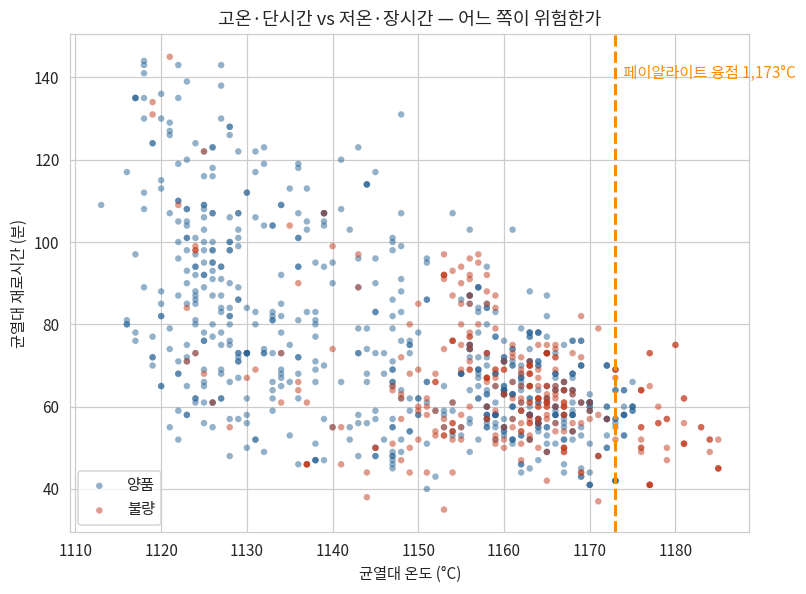

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for t, lab in [(0, "양품"), (1, "불량")]:
    d = df[df.target == t]
    ax.scatter(d["fur_soak_temp"], d["fur_soak_time"], s=18, alpha=.5,
               c=PALETTE[t], label=lab, edgecolors="none")

# 페이얄라이트 융점
ax.axvline(1173, color="darkorange", ls="--", lw=2)
ax.text(1173.5, ax.get_ylim()[1]*.95, " 페이얄라이트 융점 1,173°C",
        color="darkorange", fontsize=10, fontweight="bold", va="top")

ax.set_xlabel("균열대 온도 (°C)"); ax.set_ylabel("균열대 재로시간 (분)")
ax.set_title("고온·단시간 vs 저온·장시간 — 어느 쪽이 위험한가",
             fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout(); plt.show()

그래프 **왼쪽 위(저온·장시간)** 는 파란색(양품)이 몰려 있고,
**오른쪽 아래(고온·단시간)** 로 갈수록 빨간색(불량)이 짙어진다.
아레니우스 해석이 데이터로 확인된다.

> **현장 시사점**: 재로시간을 줄이는 것보다 **온도 상한을 관리하는 쪽**이
> 개선 효과가 크다.

### 2-4. 페이얄라이트 임계점 탐색

균열대 온도를 구간으로 잘라 불량률을 보면, 특정 온도에서 계단식으로
뛰는 지점이 있는지 확인할 수 있다. 임계점이 확인되면 그 자체로
**현장 운전 기준(운전 상한)** 이 된다.

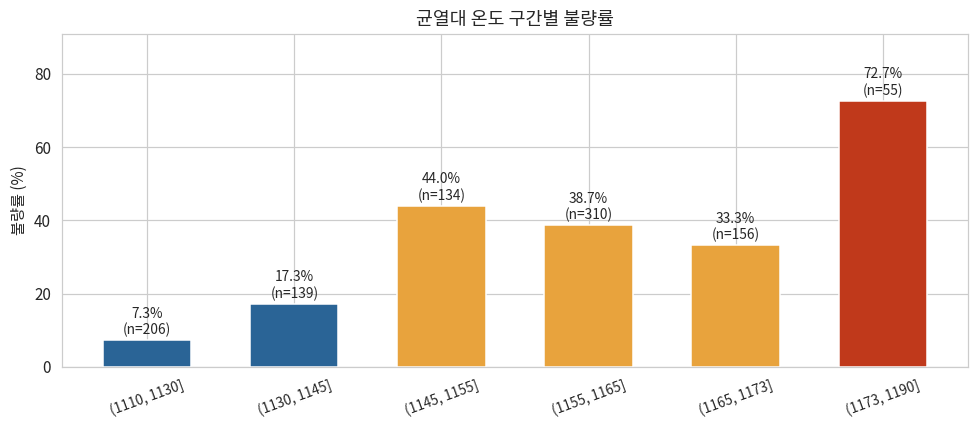

,건수,불량률
_soak_bin,,
"(1110, 1130]",206,7.3
"(1130, 1145]",139,17.3
"(1145, 1155]",134,44.0
"(1155, 1165]",310,38.7
"(1165, 1173]",156,33.3
"(1173, 1190]",55,72.7


In [8]:
bins = [1110, 1130, 1145, 1155, 1165, 1173, 1190]
df["_soak_bin"] = pd.cut(df["fur_soak_temp"], bins=bins)
tab = df.groupby("_soak_bin", observed=True).agg(
    건수=("target", "size"), 불량률=("target", lambda s: s.mean() * 100)
).round(1)

fig, ax = plt.subplots(figsize=(9, 4))
colors = [C_NG if v > 50 else "#e8a33d" if v > 30 else C_OK for v in tab["불량률"]]
ax.bar(range(len(tab)), tab["불량률"], color=colors, width=.6)
for i, (v, n) in enumerate(zip(tab["불량률"], tab["건수"])):
    ax.text(i, v + 1.5, f"{v:.1f}%\n(n={n})", ha="center", fontsize=9)
ax.set_xticks(range(len(tab)))
ax.set_xticklabels([str(i) for i in tab.index], rotation=20, fontsize=9)
ax.set_ylabel("불량률 (%)"); ax.set_ylim(0, max(tab["불량률"]) * 1.25)
ax.set_title("균열대 온도 구간별 불량률", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

display(tab)

### 2-5. HSB — 스케일 제거의 최후 방어선

`hsb`는 고압수 디스케일러(High-pressure Scale Breaker)로,
150~250bar의 고압수를 판 표면에 분사해 스케일을 열충격과 기계적 충격으로
박리시키는 설비다.

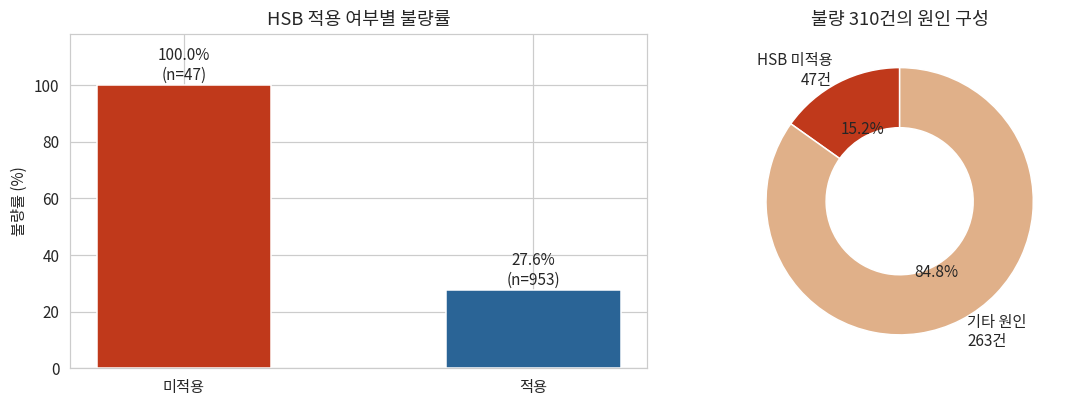

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

# (좌) HSB 적용 여부별 불량률
t1 = df.groupby("hsb")["target"].agg(["size", "mean"])
b = ax[0].bar(t1.index, t1["mean"] * 100, color=[C_NG, C_OK], width=.5)
for i, (n, m) in enumerate(zip(t1["size"], t1["mean"])):
    ax[0].text(i, m * 100 + 2, f"{m*100:.1f}%\n(n={n})", ha="center", fontsize=10)
ax[0].set_ylim(0, 118); ax[0].set_ylabel("불량률 (%)")
ax[0].set_title("HSB 적용 여부별 불량률", fontsize=12, fontweight="bold")

# (우) 불량 310건의 구성
n_nohsb = int(((df.hsb == "미적용") & (df.target == 1)).sum())
n_other = int(df.target.sum() - n_nohsb)
ax[1].pie([n_nohsb, n_other], labels=[f"HSB 미적용\n{n_nohsb}건", f"기타 원인\n{n_other}건"],
          colors=["#c0391b", "#e0b089"], autopct="%1.1f%%", startangle=90,
          wedgeprops=dict(width=.45, edgecolor="w"))
ax[1].set_title("불량 310건의 원인 구성", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

**해석 — 강력한 도메인 팩트, 그러나 전부는 아니다**

HSB 미적용 47건은 **예외 없이 100% 불량**이다. "HSB는 스케일 제거의 유일한
물리적 방어선"이라는 도메인 지식이 데이터로 완벽히 재현된다.

동시에 오른쪽 그래프가 중요하다. 이 47건은 전체 불량 310건의 **15.2%**에
불과하다. 나머지 **263건(84.8%)** 은 HSB를 정상 적용했는데도 불량이 났다.

> 통계적으로 이는 **완전분리(perfect separation)** 라 경계 대상이지만,
> 위 구성비 때문에 모델이 `hsb` 하나만 보고 끝낼 수는 없다.
> 실제 변수 중요도에서도 `hsb`는 1위가 아닌 2위로 나온다(5장 참조).
> 따라서 제거하지 않고 **도메인 팩트로 그대로 포함**시킨다.

### 2-6. 제품 치수와 HSB 노즐 커버리지

디스케일러 헤더의 노즐 배열은 고정폭이다. 판이 넓으면 폭 방향 끝단(에지부)에서
충돌압력이 떨어져 스케일이 남는다. 반대로 너무 좁으면 분사가 헛돌아
온도만 떨어진다. 즉 **최적 구간을 벗어난 양쪽 끝**이 위험하다.

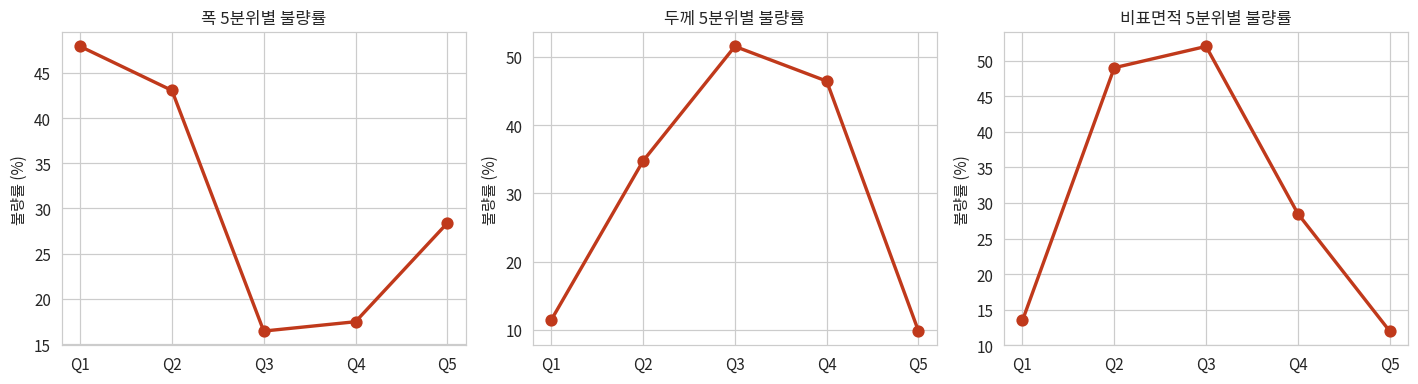

Q1=최소 구간, Q5=최대 구간
선형이 아니라 U자/역U자 형태로 나타나면 '최적 구간'이 존재한다는 뜻이다.


In [10]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for a, (col, name, unit) in zip(ax, [
        ("pt_width", "폭", "mm"), ("pt_thick", "두께", "mm"), ("sa_ratio", "비표면적", "")]):
    q = pd.qcut(df[col], 5, duplicates="drop")
    r = df.groupby(q, observed=True)["target"].mean() * 100
    a.plot(range(len(r)), r.values, marker="o", lw=2.2, color=C_NG, ms=7)
    a.set_xticks(range(len(r)))
    a.set_xticklabels([f"Q{i+1}" for i in range(len(r))])
    a.set_title(f"{name} 5분위별 불량률", fontsize=11, fontweight="bold")
    a.set_ylabel("불량률 (%)")
plt.tight_layout(); plt.show()

print("Q1=최소 구간, Q5=최대 구간")
print("선형이 아니라 U자/역U자 형태로 나타나면 '최적 구간'이 존재한다는 뜻이다.")

---
## 3. Feature Set 설계 — 데이터 누수 방지

2-2에서 `rolling_temp`가 가장 강력한 변수임을 확인했다.
그런데 이 변수는 **압연이 끝나야 확정되는 값**이다.
Scale 불량 판정 역시 압연 후에 이뤄진다.

즉 `rolling_temp`를 예측에 쓰면 **결과를 보고 결과를 맞히는** 구조가 된다.
정확도는 높지만, 현업이 조치할 시점은 이미 지나 있다.

> 시험에 비유하면 —
> **Set_A는 시험 전에 성적을 예측**하는 것이고,
> **Set_B는 답안지를 채점한 뒤 "왜 틀렸나"를 분석**하는 것이다.
> 둘 다 가치가 있지만 용도가 완전히 다르다.

| | **Set_A** | **Set_B** |
|---|---|---|
| 용도 | 사전 예측 · 실시간 경보 | 사후 분석 · XAI |
| 사용 시점 | 슬래브가 가열로를 나올 때 | 불량 판정 후 원인 규명 |
| 포함 변수 | 가열로 추출 시점까지 | 전 공정 |

In [11]:
for fs, spec in FEATURE_SETS.items():
    cat, num = get_feature_columns(fs)
    print(f"Set_{fs} — {spec['desc']}")
    print(f"  변수 {len(cat)+len(num)}개 (범주 {len(cat)} / 수치 {len(num)})")
    print()

# 하류 변수 = Set_B에만 있는 변수
down = set(get_feature_columns("B")[0] + get_feature_columns("B")[1]) - \
       set(get_feature_columns("A")[0] + get_feature_columns("A")[1])
print("Set_B에만 포함된 압연 이후 변수:", sorted(down))

Set_A — 사전 예측용 (가열로 추출 시점 변수만)
  변수 24개 (범주 7 / 수치 17)

Set_B — 사후 분석용 (압연 공정 변수 포함)
  변수 27개 (범주 8 / 수치 19)

Set_B에만 포함된 압연 이후 변수: ['descaling_count', 'rolling_method', 'rolling_temp']


---
## 4. 7개 모델 비교

### 평가 설계

대시보드에서 임계값을 슬라이더로 조정할 예정이므로, **F1@0.5로 모델 순위를
매기면 안 된다.** 0.5에서 F1이 가장 높은 모델이 0.3에서도 최고라는 보장이 없다.

- **모델 순위** → ROC-AUC / PR-AUC (임계값 무관, "줄 세우는 능력")
- **임계값** → 비용비 `k × FN + FP` 최소화

여기서 k는 **"불량 1건을 놓치는 것이 헛경보 몇 건에 해당하는가"** 이다.
0.26 같은 확률값은 현업에게 의미 없는 숫자지만, k는 엔지니어가 실제로
답할 수 있는 질문이다.

임계값은 반드시 **학습셋의 OOF(out-of-fold) 확률**에서 정한다.
테스트셋에서 찾으면 그 테스트 성능이 낙관 편향된다.

In [12]:
from models import run_comparison, MAIN_MODEL, UX_MODEL

res_a = run_comparison(df, feature_set="A", cost_ratio=5, verbose=False)
res_b = run_comparison(df, feature_set="B", cost_ratio=5, verbose=False)

cols = ["model", "ROC_AUC", "PR_AUC", "threshold",
        "Recall", "Precision", "F1", "FN", "FP", "cost", "gray_zone"]

print("=" * 90)
print("[Set_A] 사전 예측용 — 가열로 추출 시점 변수만")
print("=" * 90)
display(res_a["summary"][cols].round(3))

print("=" * 90)
print("[Set_B] 사후 분석용 — 압연 공정 변수 포함")
print("=" * 90)
display(res_b["summary"][cols].round(3))

[Set_A] 사전 예측용 — 가열로 추출 시점 변수만


,model,ROC_AUC,PR_AUC,threshold,Recall,Precision,F1,FN,FP,cost,gray_zone
0,RandomForest,0.938,0.926,0.37,0.896,0.885,0.890,8,9,49,0.832
1,XGBoost,0.937,0.906,0.32,0.857,0.846,0.852,11,12,67,0.468
2,GradientBoosting,0.926,0.904,0.23,0.909,0.787,0.843,7,19,54,0.584
3,SVM_RBF,0.916,0.875,0.28,0.831,0.780,0.805,13,18,83,0.920
4,LogisticRegression,0.901,0.854,0.32,0.870,0.691,0.770,10,30,80,0.708
5,DecisionTree,0.898,0.843,0.30,0.818,0.750,0.783,14,21,91,0.696
6,KNN,0.838,0.775,0.20,0.831,0.538,0.653,13,55,120,0.832


[Set_B] 사후 분석용 — 압연 공정 변수 포함


,model,ROC_AUC,PR_AUC,threshold,Recall,Precision,F1,FN,FP,cost,gray_zone
0,GradientBoosting,0.999,0.998,0.29,0.987,1.000,0.993,1,0,5,0.008
1,XGBoost,0.986,0.986,0.14,0.961,0.987,0.974,3,1,16,0.040
2,RandomForest,0.985,0.983,0.27,0.948,0.936,0.942,4,5,25,0.708
3,DecisionTree,0.989,0.975,0.31,0.948,1.000,0.973,4,0,20,0.008
4,SVM_RBF,0.952,0.922,0.18,0.922,0.724,0.811,6,27,57,0.704
5,LogisticRegression,0.931,0.894,0.20,0.935,0.661,0.774,5,37,62,0.588
6,KNN,0.871,0.831,0.20,0.844,0.596,0.699,12,44,104,0.776


### 회색지대(gray_zone)가 무엇인가

맨 오른쪽 `gray_zone`은 **예측 확률이 0.05~0.95 사이에 있는 샘플 비율**이다.
슬라이더를 움직였을 때 판정이 실제로 바뀔 수 있는 여지를 뜻한다.

이 값이 0에 가까우면 모델이 모든 샘플을 확신하고 있다는 뜻이고,
그러면 임계값을 아무리 조정해도 결과가 변하지 않는다.
**성능이 아무리 좋아도 대시보드 슬라이더가 장식이 된다.**

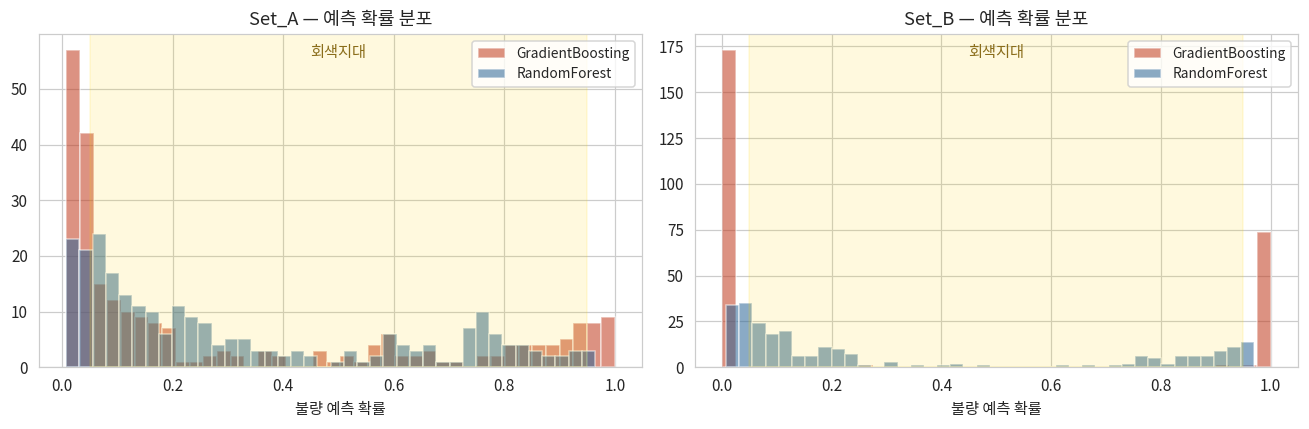

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (res, title) in zip(axes, [(res_a, "Set_A"), (res_b, "Set_B")]):
    for name, c in [(MAIN_MODEL, C_NG), (UX_MODEL, C_OK)]:
        ax.hist(res["probs"][name], bins=40, alpha=.55, label=name, color=c)
    ax.axvspan(0.05, 0.95, color="gold", alpha=.13)
    ax.text(0.5, ax.get_ylim()[1]*.93, "회색지대", ha="center",
            fontsize=10, color="#8a6d1a", fontweight="bold")
    ax.set_title(f"{title} — 예측 확률 분포", fontsize=12, fontweight="bold")
    ax.set_xlabel("불량 예측 확률"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

---
## 5. XAI — 변수 중요도 해석

트리 모델의 기본 `feature_importances_`(불순도 기반)는 카디널리티가 높은
변수를 과대평가하는 편향이 있다. 여기서는 **Permutation Importance**를 쓴다.
변수 값을 무작위로 섞었을 때 성능이 얼마나 떨어지는지를 측정하므로,
모델 종류에 무관하고 해석이 직관적이다.

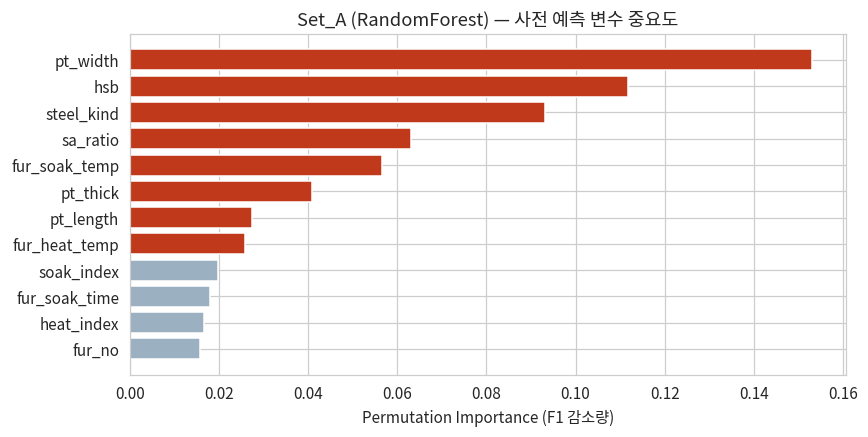

In [14]:
from sklearn.inspection import permutation_importance

def plot_importance(res, model_name, title, top=12):
    pipe = res["models"][model_name]
    x_te, y_te = res["x_test"], res["y_test"]
    pi = permutation_importance(pipe, x_te, y_te, n_repeats=20,
                                random_state=42, scoring="f1", n_jobs=-1)
    imp = (pd.Series(pi.importances_mean, index=x_te.columns)
             .sort_values(ascending=False).head(top))[::-1]

    fig, ax = plt.subplots(figsize=(8, max(3.5, len(imp) * .34)))
    ax.barh(imp.index, imp.values,
            color=[C_NG if v > 0.02 else "#9bb0c1" for v in imp.values])
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Permutation Importance (F1 감소량)")
    plt.tight_layout(); plt.show()
    return imp[::-1]

imp_a = plot_importance(res_a, UX_MODEL, f"Set_A ({UX_MODEL}) — 사전 예측 변수 중요도")

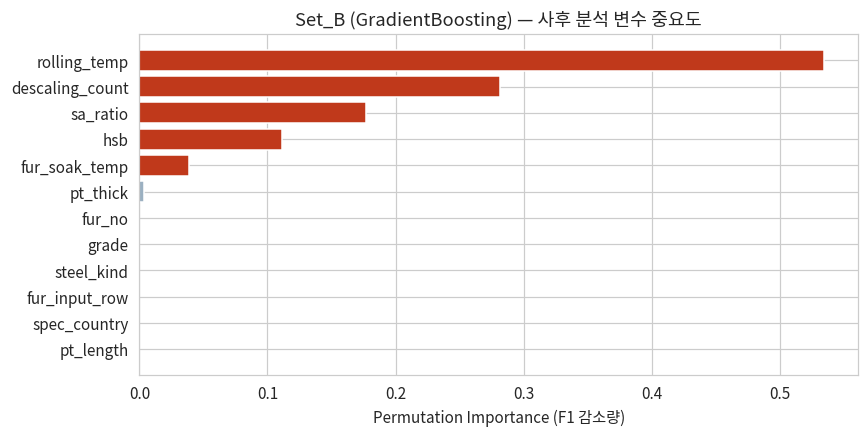

In [15]:
imp_b = plot_importance(res_b, MAIN_MODEL, f"Set_B ({MAIN_MODEL}) — 사후 분석 변수 중요도")

**해석 — 두 그림이 왜 이렇게 다른가**

Set_B에서는 `rolling_temp` 하나가 중요도를 독식하고 나머지가 거의 0으로 눌린다.
정확도는 높지만 **현업에게 해줄 말이 "압연 온도를 낮추세요" 하나뿐**이다.

반면 Set_A는 중요도가 여러 변수로 분산된다. 그리고 그 변수들이 전부
**가열로 추출 이전에 확정되는 값**이라 실제 조치가 가능하다.

> **XAI 관점에서는 Set_A가 훨씬 풍부하다.**
> 성능 몇 %p를 잃는 대신, 현업이 실행할 수 있는 레버를 여러 개 얻는다.

### SHAP — 개별 판재 단위 설명

Permutation Importance가 "전체적으로 어떤 변수가 중요한가"를 답한다면,
SHAP은 **"이 판재 한 장이 왜 불량으로 예측됐는가"** 를 답한다.
대시보드에서 오퍼레이터에게 보여줄 근거가 바로 이것이다.

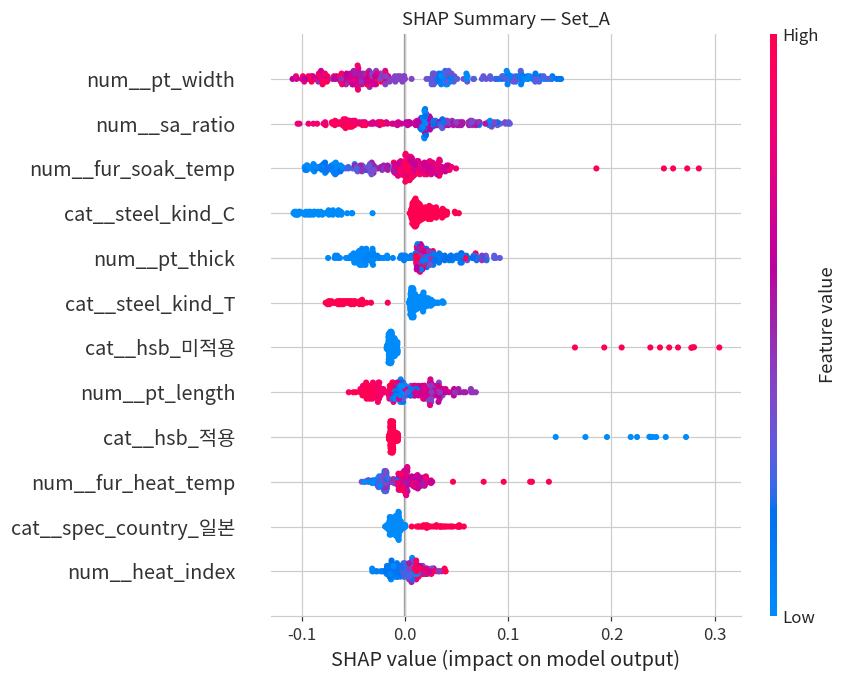

In [16]:
try:
    import shap

    pipe = res_a["models"][UX_MODEL]
    x_te = res_a["x_test"]

    # 파이프라인에서 전처리기와 모델을 분리
    prep_fitted = pipe.named_steps["prep"]
    clf = pipe.named_steps["clf"]
    x_te_enc = prep_fitted.transform(x_te)
    feat_names = prep_fitted.get_feature_names_out()

    explainer = shap.TreeExplainer(clf)
    sv = explainer.shap_values(x_te_enc)
    if isinstance(sv, list):
        sv = sv[1]
    elif sv.ndim == 3:
        sv = sv[:, :, 1]

    shap.summary_plot(sv, x_te_enc, feature_names=feat_names,
                      max_display=12, show=False)
    plt.title("SHAP Summary — Set_A", fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()

except ImportError:
    print("shap 미설치: pip install shap")

**SHAP Summary 읽는 법**

- 세로축: 중요도 순 변수
- 가로축: SHAP 값. **오른쪽(양수) = 불량 위험을 높임**, 왼쪽 = 낮춤
- 점 색깔: **빨강 = 그 변수의 값이 큼**, 파랑 = 작음

따라서 **"빨간 점이 오른쪽에 몰려 있다"** = 그 변수가 클수록 불량 위험이 커진다.
온도 변수들이 이 패턴을 보이면 도메인 가설이 개별 판재 수준에서도
확인되는 것이다.

---
## 6. 비용비 기반 임계값 최적화

대시보드에는 확률 임계값이 아니라 **비용비 k 슬라이더**를 올린다.

현업 엔지니어에게 "임계값을 0.26으로 하시겠습니까?"라고 물으면 답할 수 없다.
하지만 **"불량 1건을 놓치는 게 헛경보 몇 건 값입니까?"** 라고 물으면
품질팀과 생산팀이 협의해서 답할 수 있는 질문이 된다.

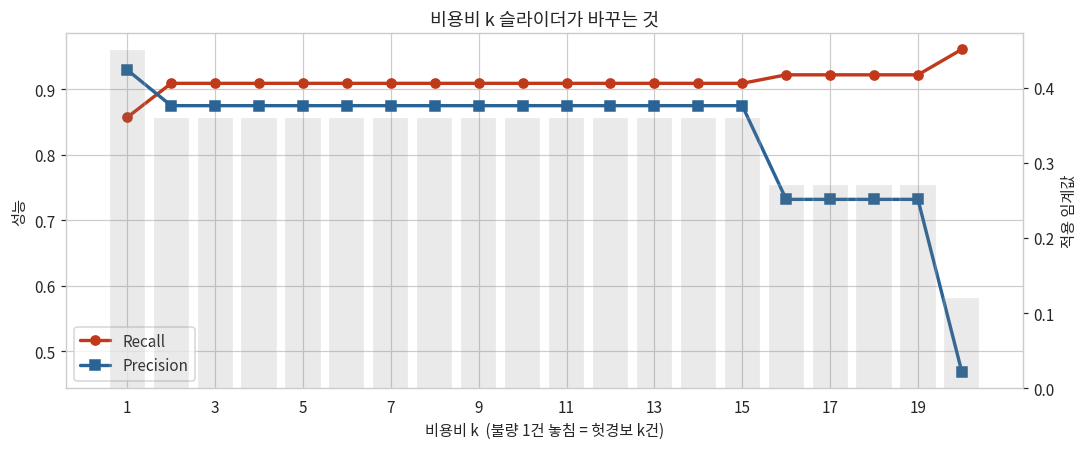

,k,threshold,Recall,Precision,FN,FP
0,1,0.45,0.857,0.930,11,5
1,2,0.36,0.909,0.875,7,10
2,3,0.36,0.909,0.875,7,10
3,4,0.36,0.909,0.875,7,10
4,5,0.36,0.909,0.875,7,10
5,6,0.36,0.909,0.875,7,10
6,7,0.36,0.909,0.875,7,10
7,8,0.36,0.909,0.875,7,10
8,9,0.36,0.909,0.875,7,10
9,10,0.36,0.909,0.875,7,10


In [17]:
from models import sweep_cost_ratio

sweep = sweep_cost_ratio(res_a["y_test"], res_a["probs"][UX_MODEL], range(1, 21))

fig, ax1 = plt.subplots(figsize=(10, 4.2))
ax1.plot(sweep["k"], sweep["Recall"], marker="o", color=C_NG, lw=2.2, label="Recall")
ax1.plot(sweep["k"], sweep["Precision"], marker="s", color=C_OK, lw=2.2, label="Precision")
ax1.set_xlabel("비용비 k  (불량 1건 놓침 = 헛경보 k건)")
ax1.set_ylabel("성능"); ax1.set_xticks(range(1, 21, 2)); ax1.legend(loc="lower left")

ax2 = ax1.twinx()
ax2.bar(sweep["k"], sweep["threshold"], alpha=.16, color="gray", label="임계값")
ax2.set_ylabel("적용 임계값"); ax2.grid(False)

ax1.set_title("비용비 k 슬라이더가 바꾸는 것", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

display(sweep.round(3))

**해석**

k를 올리면 임계값이 내려가면서 Recall이 오르고 Precision이 떨어진다.
다만 무한정 변하지는 않고 **특정 k 이상에서는 포화**된다.
슬라이더 범위를 정할 때 이 포화 지점을 참고하면 된다.

---
## 7. 결론 및 현장 적용 가이드라인

### 검증된 도메인 가설

| 가설 | 결과 | 근거 |
|---|---|---|
| 온도가 높을수록 불량 | **지지** | 온도 3종 모두 불량 쪽이 높음 (압연온도 +78.5°C) |
| 시간이 길수록 불량 | **부분 기각** | 시간 3종 모두 불량 쪽이 오히려 짧음 → 아레니우스 해석 |
| HSB 미적용 시 불량 폭증 | **강하게 지지** | 47건 100% 불량. 단 전체 불량의 15.2%에 그침 |
| 폭이 넓으면 에지부 잔류 | **지지** | Set_A 중요도 상위 |

### 현장 개선 우선순위

1. **온도 상한 관리** — 재로시간 단축보다 효과가 크다. 산화 속도가 온도에
   지수적이기 때문이다.
2. **균열대 온도 임계 관리** — 페이얄라이트 융점(1,173°C) 부근 구간의 불량률을
   확인하고 운전 상한을 설정한다.
3. **HSB 미적용 사유 조사** — 47건이 왜 미적용이었는지는 모델링이 아니라
   운전 규칙 문제다. 설비 트러블인지, 특정 강종 회피인지 확인이 필요하다.
4. **광폭재 HSB 노즐 점검** — 에지부 충돌압력 부족 여부를 실측한다.

### 대시보드 연계

- **실시간 경보 탭** → Set_A 모델. 가열로 추출 시점에 위험도를 띄운다.
- **원인 분석 탭** → Set_B 모델 + SHAP. 사후에 근본 원인을 설명한다.
- **비용비 슬라이더** → 품질팀/생산팀이 k를 조정해 경보 민감도를 직접 관리한다.

### 알려진 한계

- **`fur_ex_temp`(추출대 온도) 부재** — 도메인상 스케일 불량의 최종 방아쇠로
  알려진 변수가 데이터에 없다. 확보 시 Set_A 성능 향상이 기대된다.
- **`descaling_count` 역인과 가능성** — 불량률이 횟수에 대해 단조롭지 않다.
  스케일이 안 떨어지는 것을 보고 오퍼레이터가 추가 분사한 결과라면,
  원인이 아니라 결과의 대리 지표다. 현장 확인이 필요하다.
- **데이터 기간이 8일로 짧다** — 계절 변동, 설비 정비 주기 효과를 담지 못한다.
- **불량률 31%는 실조업 수치가 아니다** — 학습용으로 오버샘플링된 것으로
  보이므로 절대값이 아닌 상대 경향만 해석해야 한다.